**Titulo**: Sistema de Monitoreo de Productividad en el Espacio de Trabajo.

**Problema**: En un entorno de oficina o estudio, se desea detectar elementos esenciales para el trabajo (como laptops y libros) mientras se ignoran distracciones u otros objetos comunes que el modelo YOLO detecta por defecto (como botellas, tazas o personas que pasan).

**Clases Activadas**: 

    1. laptop (ID: 63)

    2. book (Libro) (ID: 73)
    
    3. cell phone (Celular) (ID: 67)

In [ ]:
import cv2
from ultralytics import YOLO

# 1. Cargar el modelo nano (ideal para GPU Intel Integradas)
model = YOLO('yolov8n.pt') 

# 2. Definir los IDs de las clases de interés (COCO Dataset IDs)
# 63: laptop, 67: cell phone, 73: book
clases_seleccionadas = [63, 67, 73]

# Diccionario para nombres 
nombres_es = {63: "Laptop", 67: "Celular", 73: "Libro"}

capture = cv2.VideoCapture(0)

while True:
    success, img = capture.read()
    if not success:
        break

    # 3. LÓGICA MODIFICADA: Filtrado directo en la inferencia
    # El parámetro 'classes' hace que YOLO ignore todo lo que no esté en la lista
    results = model(img, stream=True, imgsz=320, conf=0.4, classes=clases_seleccionadas)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            conf = float(box.conf[0])

            # Dibujar solo los objetos permitidos
            label = f'{nombres_es[cls]} {conf:.2f}'
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2) # Verde para detectados
            cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 4. Mostrar resultado
    cv2.imshow('Aplicacion de Deteccion Especifica', img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

capture.release()
cv2.destroyAllWindows()

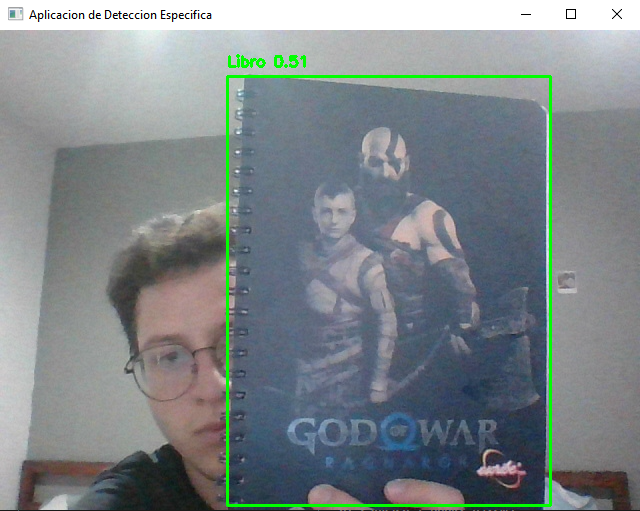
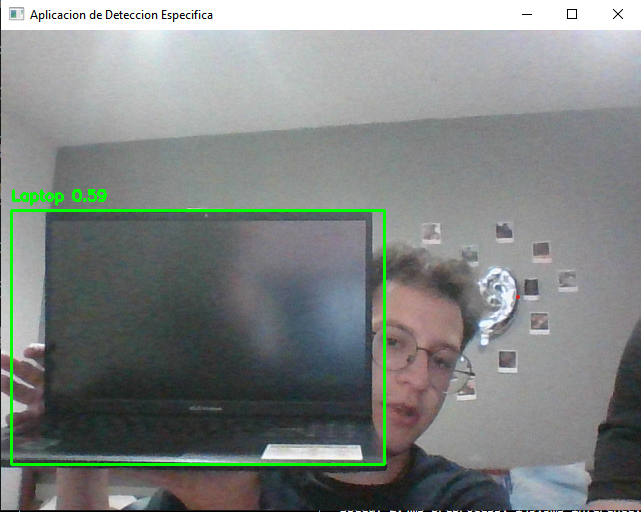
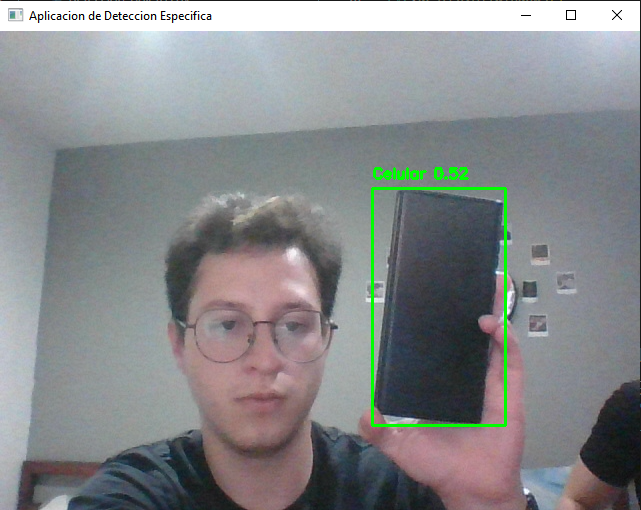
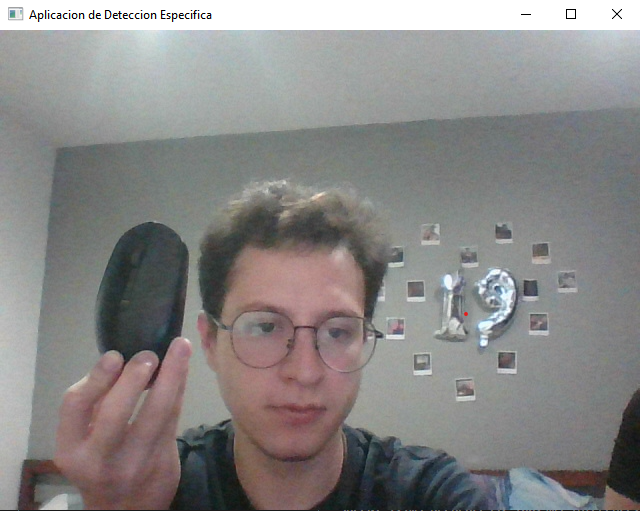
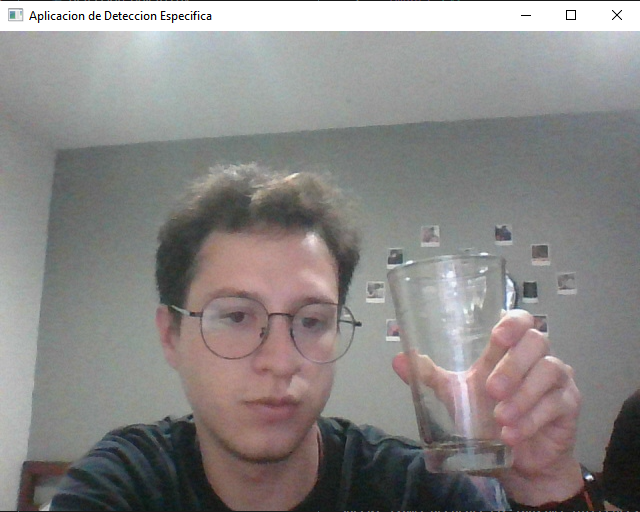
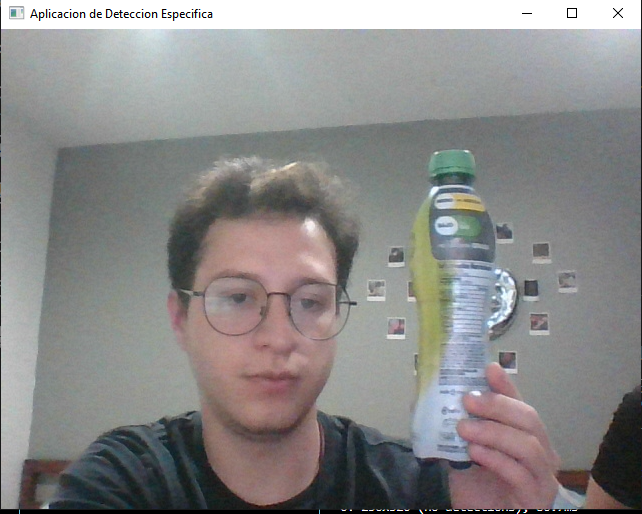
